In [1]:
import os
os.environ["PATH"] = os.path.expanduser("~/texlive/bin/x86_64-linux") + ":" + os.environ["PATH"]

import numpy as np
import matplotlib.pyplot as plt
import csiborgtools
from tqdm import trange
from h5py import File
import scienceplots
import imageio

from hmf import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_rusty)

/mnt/home/rstiskalek/csiborgtools/venv_csiborg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def load_and_convert_to_xyz(filename="2MPP.txt"):
    from astropy.cosmology import FlatLambdaCDM

    cosmo = FlatLambdaCDM(H0=100, Om0=0.306)
    data = np.loadtxt(filename)

    ra = data[:, 1]  # radians
    dec = data[:, 2]  # radians
    zo = data[:, 3]

    comoving_dist = cosmo.comoving_distance(zo).value 
    X = np.vstack([comoving_dist, np.rad2deg(ra), np.rad2deg(dec)]).T
    return csiborgtools.radec_to_cartesian(X)



In [32]:
fname = "/mnt/home/rstiskalek/ceph/CSiBORG/postprocessing/cutouts/inner_100_cutouts.hdf5"
# fname = "/mnt/home/rstiskalek/ceph/CSiBORG/postprocessing/cutouts/Virgo_15hMpc_cutouts.hdf5"
mask_width = 100
name = "inner"
grid = 256

density_obj = csiborgtools.field.DensityField(mask_width, "TSC")
rho = np.zeros((grid, grid), dtype=np.float32)
ax = 2
# pos_virgo = csiborgtools.clusters["Virgo"].cartesian_pos(681.1) - 681.1 / 2
pos_virgo = np.asarray([0, 0, 0.])


pos_2mpp = load_and_convert_to_xyz() - pos_virgo
pos_2mpp_box = pos_2mpp[np.all(np.abs(pos_2mpp) < mask_width / 2, axis=1)]

with File(fname, 'r') as f:
    ntot = 0
    pos = []
    mass = []
    for n in trange(2):
        pos = f[f"step_{n}/pos"][...]
        mass = f[f"step_{n}/mass"][...]
        rho += density_obj.density_2d(pos, mass, ax, grid, verbose=False)
        ntot += 1
    rho /= ntot


100%|██████████| 2/2 [00:06<00:00,  3.48s/it]


Saving inner_2.png


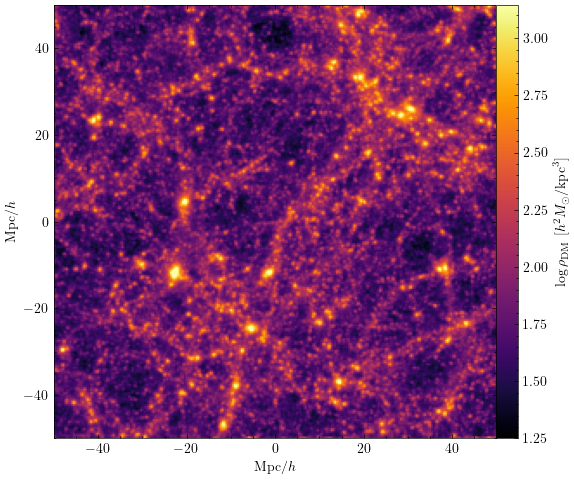

Saving inner_2_with_galaxies.png


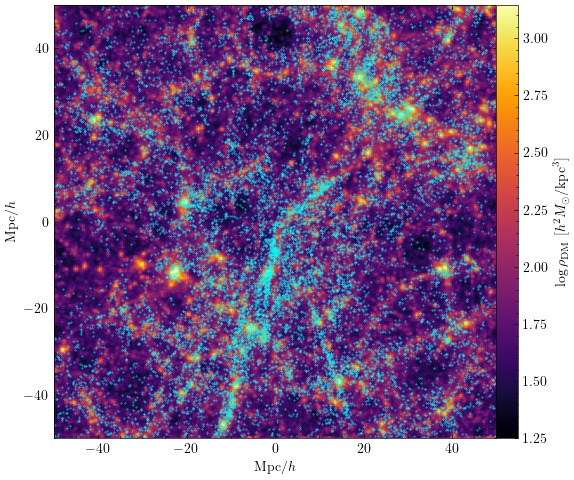

In [35]:
extent = (-mask_width / 2, mask_width / 2, -mask_width / 2, mask_width / 2)
img = np.log10(1 + rho)

vmin = 1.25
vmax = np.percentile(img.flatten(), 99.9)

def make_plot(with_galaxies=False):
    with plt.style.context("science"):
        plt.figure(figsize=(6, 5))
        plt.imshow(img, extent=extent, origin="lower", aspect="auto",
                   cmap="inferno", vmin=vmin, vmax=vmax)

        plt.colorbar(label=r"$\log \rho_{\rm DM} ~ [h^2 M_\odot / \mathrm{kpc}^3]$", pad=0)
        plt.xlabel(r"$\mathrm{Mpc} / h$")
        plt.ylabel(r"$\mathrm{Mpc} / h$")

        if with_galaxies:
            kwargs = dict(s=0.1, c="cyan")
            if ax == 0:
                plt.scatter(pos_2mpp_box[:, 2], pos_2mpp_box[:, 1], **kwargs)
            elif ax == 1:
                plt.scatter(pos_2mpp_box[:, 2], pos_2mpp_box[:, 0], **kwargs)
            elif ax == 2:
                plt.scatter(pos_2mpp_box[:, 1], pos_2mpp_box[:, 0], **kwargs)

        plt.tight_layout()
        suffix = "_with_galaxies" if with_galaxies else ""
        fname = f"{name}_{ax}{suffix}.png"
        print(f"Saving {fname}")
        plt.savefig(fname, dpi=500)
        plt.show()

# Save both versions
make_plot(with_galaxies=False)
make_plot(with_galaxies=True)



In [25]:
grid = 1024
ax = 2
name = "inner"
gif_path = f"{name}_density_evolution_ax{ax}.gif"
outdir = "scratch"


# First pass to get vmin/vmax for consistent scaling
all_imgs = []
with File(fname, 'r') as f:
    for n in trange(40, desc="Scanning for vmin/vmax"):
        pos = f[f"step_{n}/pos"][...]
        mass = f[f"step_{n}/mass"][...]
        rho = density_obj.density_2d(pos, mass, ax, grid, verbose=False)
        img = np.log10(1 + rho)
        all_imgs.append(img)

vmin = 1.5
vmax = np.percentile(np.concatenate([img.flatten() for img in all_imgs]), 99.9)

# Save frames
print("Saving frames...")
frame_paths = []
for n, img in enumerate(all_imgs):
    with plt.style.context("science"):
        plt.figure(figsize=(6, 5))
        plt.imshow(img, extent=extent, origin="lower", aspect="auto",
                   cmap="inferno", vmin=vmin, vmax=vmax)
        plt.xlabel(r"$\mathrm{Mpc} / h$")
        plt.ylabel(r"$\mathrm{Mpc} / h$")
        plt.tight_layout()
        fpath = os.path.join(outdir, f"frame_{n:03d}.png")
        plt.savefig(fpath, dpi=300)
        plt.close()
        frame_paths.append(fpath)

import imageio.v3 as iio

frames = [iio.imread(f) for f in frame_paths]

# Save as video (e.g., .mp4)
iio.imwrite("output.mp4", frames, fps=1.5, codec="libx264")  # 2 frames/sec


print("GIF created successfully.")

Scanning for vmin/vmax:   0%|          | 0/40 [00:00<?, ?it/s]

Scanning for vmin/vmax: 100%|██████████| 40/40 [00:08<00:00,  4.94it/s]


Saving frames...


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1740, 1440) to (1744, 1440) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x68817c0] Stream #0: not enough frames to estimate rate; consider increasing probesize


GIF created successfully.
